In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

In [11]:
import pandas as pd

def import_csv(file):
    # Read the file into a DataFrame: df
    import pandas as pd
    return pd.read_csv(file)

In [13]:
Rosedata2_df = import_csv("Occurrence_ext.csv")
print(Rosedata2_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1585 entries, 0 to 1584
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   collection_code           1585 non-null   object
 1   event_id                  1585 non-null   object
 2   catalog_number            1585 non-null   int64 
 3   occurrence_id             1585 non-null   object
 4   scientific_name           1585 non-null   object
 5   identification_qualifier  234 non-null    object
 6   individual_count          1585 non-null   int64 
 7   class                     1585 non-null   object
 8   feeding_type              1585 non-null   object
 9   life_mode                 1585 non-null   object
 10  habitat                   1585 non-null   object
dtypes: int64(2), object(9)
memory usage: 136.3+ KB
None


In [16]:
print(Rosedata2_df.head())
print("\nAvailable columns:", Rosedata2_df.columns.tolist())
print("\nUnique values in 'habitat':", Rosedata2_df['habitat'].unique())

  collection_code   event_id  catalog_number occurrence_id  \
0              GG  GG_GG01R1               1   CIM-UH_GG_1   
1              GG  GG_GG01R1               2   CIM-UH_GG_2   
2              GG  GG_GG01R1               3   CIM-UH_GG_3   
3              GG  GG_GG01R1               4   CIM-UH_GG_4   
4              GG  GG_GG01R1               5   CIM-UH_GG_5   

             scientific_name identification_qualifier  individual_count  \
0  Ailinzebina elegantissima                      NaN                 4   
1          Atlantilux exigua                      NaN                 1   
2                       Atys                     spp.                 2   
3       Barbatia domingensis                      NaN                 7   
4          Caecum antillarum                      NaN                 1   

        class       feeding_type life_mode     habitat  
0  Gastropoda         Herbivores   Benthic  coral reef  
1  Gastropoda         Carnivores   Benthic  coral reef  
2  Ga

In [17]:
df_grouped = Rosedata2_df.groupby(['scientific_name', 'habitat'])['individual_count'].sum().reset_index()

df_pivot = df_grouped.pivot(index='habitat', columns='scientific_name', values='individual_count').fillna(0)

In [18]:
df_pivot = df_grouped.pivot(index='habitat', columns='scientific_name', values='individual_count').fillna(0)

In [20]:
df_pivot = df_pivot.loc[:, (df_pivot > 0).any(axis=0)]

print("\nHabitat abundance matrix:")
print(df_pivot)


Habitat abundance matrix:
scientific_name  Abra   Aclophora sagei  Acorylus gouldii  Acteocina   \
habitat                                                                 
coral reef         0.0              3.0               0.0         6.0   
seagrass           1.0              0.0               1.0         6.0   

scientific_name  Acteocina candei  Acteocina lepta  Acteocina recta  \
habitat                                                               
coral reef                    8.0             16.0              4.0   
seagrass                      2.0             14.0              0.0   

scientific_name  Agathistoma fasciatum  Agathistoma hotessierianum  \
habitat                                                              
coral reef                        46.0                         2.0   
seagrass                          17.0                         1.0   

scientific_name  Agathistoma lividomaculatum  ...  Volvarina albolineata  \
habitat                               

In [21]:
def plot_rank_abundance(data, title):
    #Sort species from higher to lower abundance
    ranked = data.sort_values(ascending=False)
    ranked = ranked[ranked > 0]  # Filter species abundance > 0
    
    #Creating dataframe for plotting
    plot_df = pd.DataFrame({
        'Species': ranked.index,
        'Abundance': ranked.values,
        'Relative_abundance': ranked.values / ranked.values.sum()
    })
    plot_df['Rank'] = range(1, len(plot_df) + 1)
    
    #Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(plot_df['Rank'], plot_df['Abundance'], 
             marker='o', linestyle='-', linewidth=2, markersize=8)
    
    #Adding labels
    for i, row in plot_df.iterrows():
        plt.text(row['Rank'], row['Abundance'], row['Species'], 
                 fontsize=9, ha='left', va='bottom', rotation=45)
    
    #Customization
    plt.title(f'Rank-Abundance curve - {title}', fontsize=14)
    plt.xlabel('Rank (1 = more abundant)', fontsize=12)
    plt.ylabel('Abundance', fontsize=12)
    plt.yscale('log')  # Log scale for better visualization
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(plot_df['Rank'])
    plt.tight_layout()

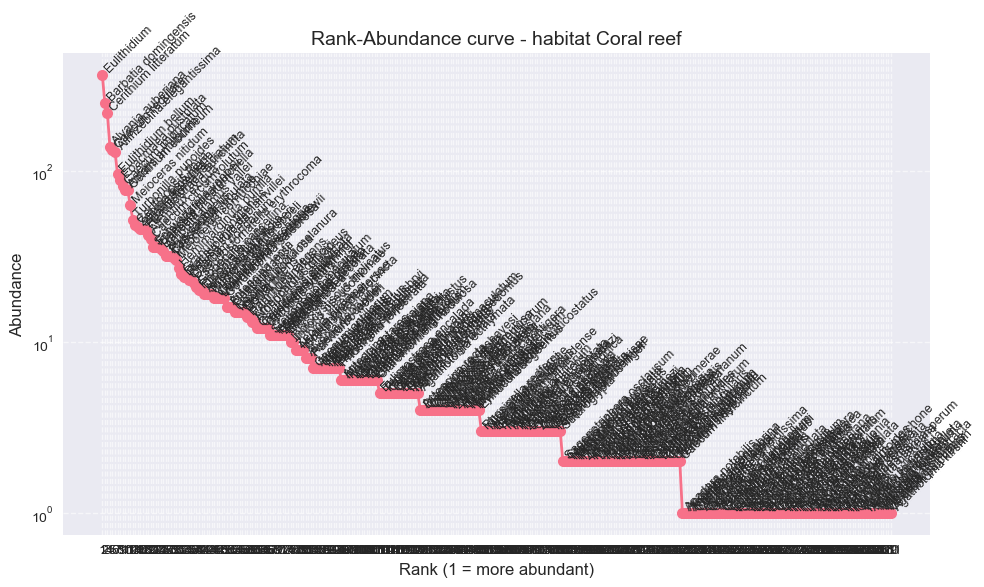

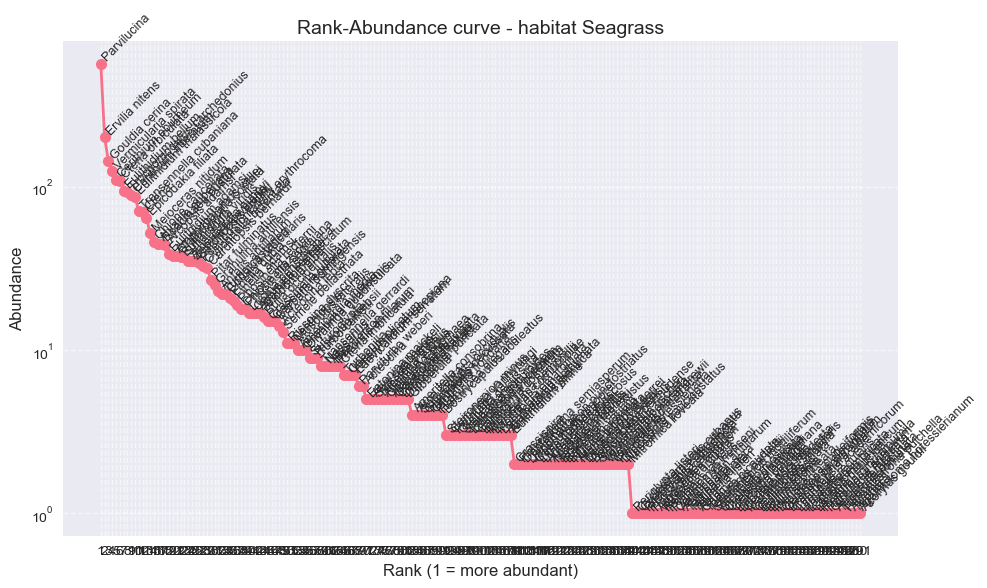

In [23]:
for habitat in df_pivot.index:
    season_data = df_pivot.loc[habitat]
    plot_rank_abundance(season_data, f'habitat {habitat.capitalize()}')
    plt.show()

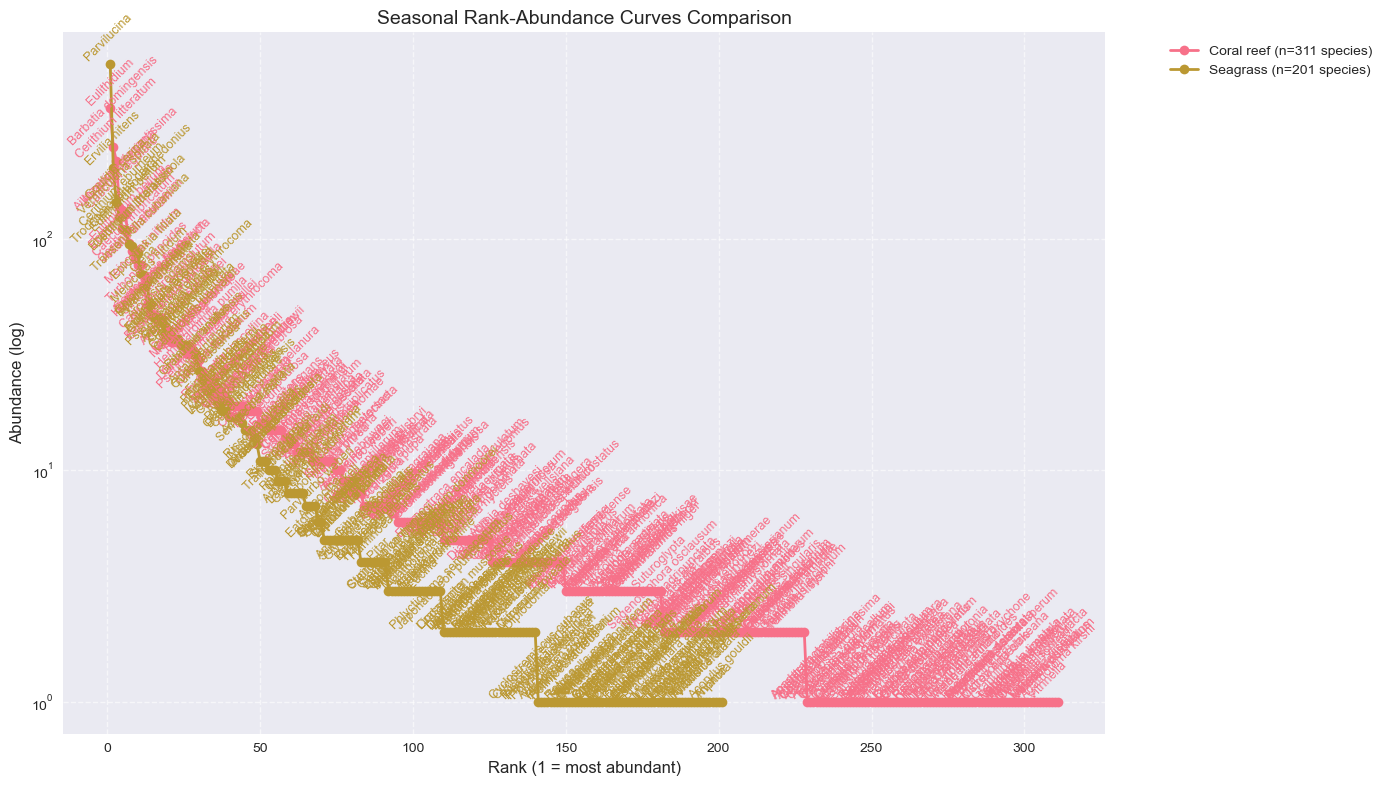

In [24]:
range = __builtins__.range

#Set the plot size and define labels position
plt.figure(figsize=(14, 8))

label_positions = {}

for season in df_pivot.index:
    season_data = df_pivot.loc[season].sort_values(ascending=False)
    season_data = season_data[season_data > 0]
    
    #Define plot aesthetic
    line, = plt.plot(
        list(range(1, len(season_data)+1)), 
        season_data.values,
        marker='o',
        linestyle='-',
        linewidth=2,
        label=f'{season.capitalize()} (n={len(season_data)} species)'
    )
    
    #Define rango as plotting variable
    for rango, (species, abundance) in enumerate(season_data.items(), start=1):
        #Adjusting vertical position
        y_offset = 1.05 if season == 'norte' else 0.95 if season == 'dry' else 1.0
        y_pos = abundance * y_offset
        
        #verify existing position
        key = (rango, species)
        if key in label_positions:
            y_pos = max(y_pos, label_positions[key] * 1.1)
        
        label_positions[key] = y_pos
        
        plt.text(
            rango,
            y_pos,
            species,
            fontsize=9,
            ha='center',
            va='bottom',
            rotation=45,
            color=line.get_color()
        )

plt.title('Seasonal Rank-Abundance Curves Comparison', fontsize=14)
plt.xlabel('Rank (1 = most abundant)', fontsize=12)
plt.ylabel('Abundance (log)', fontsize=12)
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()